              Student Performance Prediction Using Machine Learning
              
1. Introduction

Educational institutions are constantly seeking ways to improve student academic performance. One approach is to analyze historical academic data and identify patterns that influence student success.

This project develops a machine learning model that predicts students' final exam scores (G3) using academic and socio-demographic features such as study time, number of past failures, parental education level, and class attendance.

By predicting student performance early, educators can provide targeted interventions to students who may be at risk of poor academic outcomes.

2. Problem Statement

Many schools lack tools to identify students who may perform poorly before final examinations.

Without early insights, students who struggle academically may not receive the necessary support in time.

This project aims to use machine learning techniques to predict student final exam scores, allowing educators to identify risk factors affecting student performance.

3. Objectives of the Study
General Objective

To develop a machine learning model capable of predicting student final exam scores based on academic and demographic features.

Specific Objectives

To preprocess and clean the student performance dataset

To explore relationships between student attributes and exam scores

To train multiple machine learning regression models

To evaluate and compare model performance

To build a predictive system that estimates students' final exam scores

4. Dataset Description

The dataset used in this project is the Student Performance Dataset, which contains academic records and background information about students.

The dataset includes features such as:

Feature	Description
age	Student age
studytime	Weekly study time
failures	Number of past class failures
absences	Number of school absences
G1	First period grade
G2	Second period grade
G3	Final exam grade
Medu	Mother's education level
Fedu	Father's education level
internet	Internet access at home

The target variable in this study is:

G3 — Final Exam Score

The goal of the model is to predict the value of this variable.

5. Data Preprocessing

Data preprocessing is an important step in machine learning because raw datasets often contain inconsistencies, missing values, or categorical variables that need transformation.

Several preprocessing steps were performed to prepare the dataset for model training.

5.1 Handling Missing Values

Missing values were checked using:

df.isna().sum()

Where missing values were present, appropriate strategies such as mean or mode imputation were applied depending on the data type.

5.2 Encoding Categorical Variables

Machine learning models require numerical input, therefore categorical variables were converted into numerical form.

This was achieved using one-hot encoding with the help of the pandas library.

Example categorical variables encoded include:

sex

address

parent occupation

subject

Binary variables such as internet access were mapped as:

yes → 1
no → 0
5.3 Feature Scaling

Feature scaling was performed using StandardScaler from scikit-learn.

Scaling ensures that numerical variables with different ranges do not disproportionately influence the model.

Examples of scaled features include:

age

studytime

failures

absences

G1

G2

6. Feature Selection

Feature selection was performed to reduce model complexity and prevent overfitting.

Only the most relevant features were used as input variables.

Selected features include:

G1

G2

studytime

failures

absences

Medu

Fedu

schoolsup

famsup

internet

sex_M

Target variable:

G3

7. Model Development

To determine the most effective model for predicting student exam scores, multiple regression algorithms were trained and compared.

The models used include:

Linear Regression

Random Forest Regressor

Gradient Boosting Regressor

These models were implemented using the scikit-learn.

Training multiple models allows comparison of their predictive performance.

8. Model Evaluation

The models were evaluated using the following performance metrics:

Metric	Description
MAE	Mean Absolute Error
RMSE	Root Mean Squared Error
R²	Coefficient of Determination

The evaluation results were:

Model	MAE	RMSE	R²
Linear Regression	0.958	1.725	0.807
Random Forest	0.997	1.811	0.787
Gradient Boosting	1.022	1.794	0.791

Based on these results, Linear Regression produced the best performance.

9. Model Interpretation

To better understand how the model makes predictions, explainable AI techniques were applied.

Feature importance analysis revealed that the most influential predictors of final exam performance include:

Second period grade (G2)

First period grade (G1)

Study time

Number of past failures

Absences

These findings suggest that previous academic performance strongly influences final exam results.

10. Deployment of the Model

To make the model accessible and interactive, a web-based dashboard was developed using Streamlit.

The application allows users to:

input student academic information

predict final exam scores

display predicted grades

provide recommendations for academic improvement

This interactive system demonstrates the practical application of machine learning in educational analytics.

11. Conclusion

This project demonstrated how machine learning can be used to predict student academic performance.

The results indicate that previous grades and study-related factors are strong indicators of final exam success.

Such predictive systems can assist educators in identifying students who may require additional academic support.

12. Future Work

Future improvements to this project may include:

incorporating larger educational datasets

applying deep learning models

developing a complete educational analytics dashboard

integrating classification models for pass/fail prediction


In [2]:
#import Libraries
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 


IMPORT LIBRARIES 
In this section, the necessary libraries for data manipulation, visualization, and machine learning are imported. These libraries will be used throughout the project for data preprocessing, model training, evaluation, and visualization.

In [3]:
#LOAD DATASETS
math_df = pd.read_csv(r"C:\Users\USER\Desktop\my current project\student\student-mat.csv",sep=';')
por_df = pd.read_csv(r"C:\Users\USER\Desktop\my current project\student\student-por.csv",sep=';')


Load the DatasetS
The dataset containing student academic information is loaded into the notebook. This dataset includes demographic features, academic performance indicators, and the final exam score which will serve as the target variable.

In [4]:
#CREATE LABEL'SUBJECT' 
math_df['subject']= 'Math'
por_df['subject'] = 'Portuguese'

In [10]:
#Append the Portuguese and Math Dataset 
df = pd.concat([math_df,por_df],ignore_index=True)
df


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,Math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,Math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,Math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,Math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,Math
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039,MS,F,19,R,GT3,T,2,3,services,other,...,4,2,1,2,5,4,10,11,10,Portuguese
1040,MS,F,18,U,LE3,T,3,1,teacher,services,...,3,4,1,1,1,4,15,15,16,Portuguese
1041,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,5,6,11,12,9,Portuguese
1042,MS,M,17,U,LE3,T,3,1,services,services,...,4,5,3,4,2,6,10,10,10,Portuguese


The mathematics and Portuguese student datasets are combined to create a unified dataset for analysis. A new column called subject is added to distinguish between the two subjects.

In [13]:
#Shape of the combined dataset
df.shape

(1044, 34)

In [14]:
#Data cleaning and Preprocessing 
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object
 20  higher  

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [15]:
#checking missing values 
df.isna().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
subject       0
dtype: int64

In this step, we examine the structure of the dataset to understand the number of observations, features, and data types present.
Missing values can negatively affect model performance. Therefore, we check the dataset for any missing values and determine appropriate strategies for handling them.

In [16]:
# Automatically detect categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Convert detected columns to 'category' dtype
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [17]:
categorical_cols

['school',
 'sex',
 'address',
 'famsize',
 'Pstatus',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'subject']

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   school      1044 non-null   category
 1   sex         1044 non-null   category
 2   age         1044 non-null   int64   
 3   address     1044 non-null   category
 4   famsize     1044 non-null   category
 5   Pstatus     1044 non-null   category
 6   Medu        1044 non-null   int64   
 7   Fedu        1044 non-null   int64   
 8   Mjob        1044 non-null   category
 9   Fjob        1044 non-null   category
 10  reason      1044 non-null   category
 11  guardian    1044 non-null   category
 12  traveltime  1044 non-null   int64   
 13  studytime   1044 non-null   int64   
 14  failures    1044 non-null   int64   
 15  schoolsup   1044 non-null   category
 16  famsup      1044 non-null   category
 17  paid        1044 non-null   category
 18  activities  1044 non-null   category
 19  nurser

In [19]:
#Encoding norminal variables
df = pd.get_dummies(df, columns = ['sex','address','Mjob', 'Fjob','subject'],
                    drop_first =True)

In [20]:
#Encoding binary variables (yes/no)
binary_cols = ['schoolsup','famsup','paid','activities','nursery','higher','internet','romantic']

for col in binary_cols:
    df[col] = df[col].map({'yes':1, 'no':0})

Machine learning algorithms require numerical inputs. Therefore, categorical variables such as gender, address type, and parental occupation are converted into numerical format using one-hot encoding.
Some variables in the dataset contain binary values such as yes or no. These values are mapped into numerical representations to make them suitable for machine learning models.


In [21]:
#Normalizing/Scalling numeric features 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_features = [
    'age','Medu','Fedu','traveltime','studytime','failures',
    'famrel','freetime','goout','Dalc','Walc','health',
    'absences','G1','G2']

df[numeric_features] = scaler.fit_transform(df[numeric_features])

Feature scaling is applied to normalize numerical features so that they contribute equally to the machine learning model. StandardScaler from the scikit-learn is used to standardize the selected numerical variables.

In [22]:
# Splitting dataset into features and target
feature_cols = [
    'G1', 'G2', 'studytime', 'failures', 'absences',
    'Medu', 'Fedu', 'schoolsup', 'famsup', 'internet', 'sex_M']

X = df[feature_cols]  # Features
y = df['G3']          # Target

In [23]:
#splitting into training and test sets 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

The dataset is split into training and testing sets to evaluate the performance of the machine learning models on unseen data.
The dataset is separated into input features (X) and the target variable (y). The target variable is the final exam score (G3), while the remaining variables serve as predictors.

In [25]:
#Importing models and metrics 
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [26]:
#Linear Regression (Baseline Model)
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)

#Evaluate 
print('Linear Regression : ')
print('R^2:', r2_score(y_test, y_pred_lr))
print('RMSE:', np.sqrt(mean_squared_error(y_test,y_pred_lr)))
print('MAE:', mean_absolute_error(y_test, y_pred_lr))



Linear Regression : 
R^2: 0.8075185225672553
RMSE: 1.7250858327520784
MAE: 0.9582285912571449


In [27]:
#Random Forest 
rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)
#Evaluate 
print('Linear Regression : ')
print('R^2:', r2_score(y_test, y_pred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_test,y_pred_rf)))
print('MAE:', mean_absolute_error(y_test, y_pred_rf))

Linear Regression : 
R^2: 0.7878448419750406
RMSE: 1.8111025176438034
MAE: 0.9974371162177763


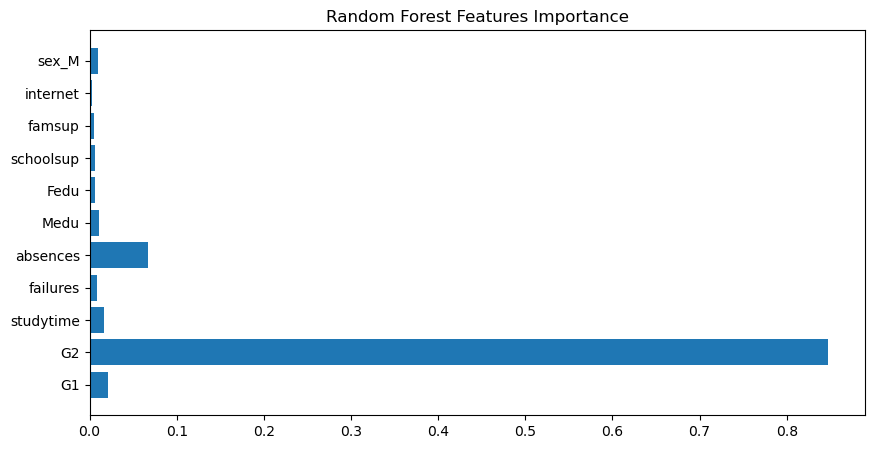

In [28]:
#Feature Importance 
importances = rf.feature_importances_
plt.figure(figsize=(10,5))
plt.barh(feature_cols,importances)
plt.title('Random Forest Features Importance')
plt.show()


Gradient Boosting Regressor:
R²: 0.7917698252971926
RMSE: 1.7942711266181055
MAE: 1.022491598443695


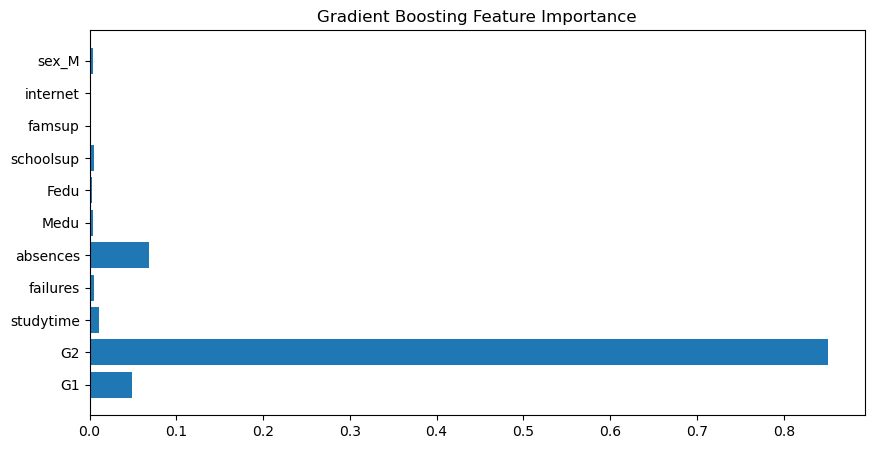

In [29]:
# Gradient Boosting
gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

# Evaluate
print("\nGradient Boosting Regressor:")
print("R²:", r2_score(y_test, y_pred_gbr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gbr)))
print("MAE:", mean_absolute_error(y_test, y_pred_gbr))

# Feature importance
importances = gbr.feature_importances_
plt.figure(figsize=(10,5))
plt.barh(feature_cols, importances)
plt.title("Gradient Boosting Feature Importance")
plt.show()

In [30]:
#Looking for the highest R^2
print('Values of R^2')
print("R²:", r2_score(y_test, y_pred_gbr),'GRADIENT BOOSTING ')
print("R²:", r2_score(y_test, y_pred_lr), 'LINEAR REGRESSION')
print("R²:", r2_score(y_test, y_pred_rf), 'RANDOM FOREST REGRESSOR')

Values of R^2
R²: 0.7917698252971926 GRADIENT BOOSTING 
R²: 0.8075185225672553 LINEAR REGRESSION
R²: 0.7878448419750406 RANDOM FOREST REGRESSOR


In [31]:
#Looking for the values with the lowest RMSE
print('Values of RMSE')
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gbr)),'GRADIENT BOOSTING')
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)),'LINEAR REGRESSION')
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)), 'RANDOM FOREST REGRESSOR')


Values of RMSE
RMSE: 1.7942711266181055 GRADIENT BOOSTING
RMSE: 1.7250858327520784 LINEAR REGRESSION
RMSE: 1.8111025176438034 RANDOM FOREST REGRESSOR


In [32]:
#Looking for the value with the lowest MAE
print('Values of MAE')
print('MAE:', mean_absolute_error(y_test, y_pred_gbr),'GRADIENT BOOSTING')
print('MAE:', mean_absolute_error(y_test, y_pred_lr),'LINEAR REGRESSION')
print('MAE:', mean_absolute_error(y_test, y_pred_rf),'RANDOM FOREST')

Values of MAE
MAE: 1.022491598443695 GRADIENT BOOSTING
MAE: 0.9582285912571449 LINEAR REGRESSION
MAE: 0.9974371162177763 RANDOM FOREST


In [33]:
!pip install streamlit joblib shap 

In [34]:
import joblib 
joblib.dump(lr,'student_score_model.pkl')

['student_score_model.pkl']

Conclusion

The machine learning models were successfully trained to predict student final exam scores. Among the evaluated models, Linear Regression demonstrated the best predictive performance. The results highlight the importance of previous academic performance and study-related factors in determining student success
